# **Implementación del caso de 5 Qubits**

In [15]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
seed = 99

In [17]:
N5 = 48567227

In [18]:
fiveQubit = SchnorrAlgQAOA(N5, 4, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 25


In [19]:
B5, t5 = fiveQubit.generate_cvp(10)
print(f'B5 = \n{B5}')
print(f't5 = \n{t5}')

B5 = 
[ 2 0 0 0 0  6931 ]
[ 0 1 0 0 0 10986 ]
[ 0 0 3 0 0 16094 ]
[ 0 0 0 2 0 19459 ]
[ 0 0 0 0 1 23979 ]
t5 = 
(0, 0, 0, 0, 0, 176985)


In [20]:
D5, b5_op, res5_vector, sign_step5, w5, dist5 = fiveQubit.babai_algorithm(B5, t5, delta = 0.75)
print(f'D5 = \n{D5}\n')
print(f'b5_op = \n{b5_op}\n')
print(f'res5_vector = \n{res5_vector}\n')
print(f'sign_step5 = \n{sign_step5}\n')
print(f'w5 = \n{w5}\n')
print(f'dist5 = \n{dist5}\n')

D5 = 
[  6 -4  6  4 -2  -3 ]
[ -8 -3  6 -2  2   5 ]
[  2 11  3  0 -6  -3 ]
[ -4 -5  0 12 -2   4 ]
[ -4 -3 -3  4  1 -17 ]

b5_op = 
[     2      4      9      8      0 176993]

res5_vector = 
[-2 -4 -9 -8  0 -8]

sign_step5 = 
[-1 -1 -1 -1  1]

w5 = 
(-3092, -354, -1837, 3883, -8732)

dist5 = 
15.132745950421556



In [21]:
qubo5 = fiveQubit.define_qubo(D5, res5_vector, sign_step5)
print(qubo5.prettyprint())
Hc5, offset5 = fiveQubit.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  117*z_0^2 - 54*z_0*z_1 + 14*z_0*z_2 + 72*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  - 116*z_1*z_2 + 78*z_1*z_3 + 136*z_1*z_4 + 179*z_2^2 - 126*z_2*z_3
  + 10*z_2*z_4 + 205*z_3^2 - 18*z_3*z_4 + 340*z_4^2 - 116*z_0 - 100*z_1
  - 102*z_2 - 200*z_3 - 302*z_4 + 229

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 292.0
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j, -32. +0.j,  16. +0.j,  -4. +0.j, -33.5+0.j, -13.5+0.j,
   3.5+0.j,  18. +0.j, -17.5+0.j, -29. +0.j,  19.5+0.j,  34. +0.j,
 -31.5+0.j,   2.5+0.j,  -4.5+0.j])


In [22]:
circuit5 = fiveQubit.construct_circuit(Hc5, reps= 1)
print(circuit5.decompose(reps = 2))

     ┌────────────┐ ┌─────────────┐                                »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(18*γ[0]) ├───■────────────────■───────────»
     ├────────────┤┌┴─────────────┴─┐ │ZZ((-27)*γ[0])  │           »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-64)*γ[0]) ├─■────────────────┼───────────»
     ├────────────┤└┬─────────────┬─┘                  │ZZ(7*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(32*γ[0]) ├────────────────────■───────────»
     ├────────────┤┌┴─────────────┴┐                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-8)*γ[0]) ├───────────────────────────────»
     ├────────────┤├───────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-67)*γ[0]) ├──────────────────────────────»
     └────────────┘└────────────────┘                              »
«                                                                   »
«q_0: ──────────────────■───────────────────────────■───────────────»
«                       │                           │               »
«q_1: ─■────────────────┼──────

In [23]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
optParameters10 = fiveQubit.qaoa_algorithm(circuit5, Hc5, x0)

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [24]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.38308200662456765
γ[0] = 0.010043564939717822


In [25]:
results5= fiveQubit.sample_from_parameters(circuit5, optParameters10, shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

32
Bistring: 00111 -> Counts: 1090
Bistring: 01100 -> Counts: 1025
Bistring: 10001 -> Counts: 929
Bistring: 01110 -> Counts: 743
Bistring: 11101 -> Counts: 698
Bistring: 00000 -> Counts: 634
Bistring: 00001 -> Counts: 618
Bistring: 00011 -> Counts: 587
Bistring: 11100 -> Counts: 554
Bistring: 01111 -> Counts: 511
Bistring: 01000 -> Counts: 402
Bistring: 00110 -> Counts: 379
Bistring: 11000 -> Counts: 232
Bistring: 11001 -> Counts: 221
Bistring: 01101 -> Counts: 215
Bistring: 10111 -> Counts: 204
Bistring: 10000 -> Counts: 165
Bistring: 10101 -> Counts: 158
Bistring: 00010 -> Counts: 141
Bistring: 00101 -> Counts: 89
Bistring: 11111 -> Counts: 82
Bistring: 01001 -> Counts: 79
Bistring: 00100 -> Counts: 71
Bistring: 11010 -> Counts: 40
Bistring: 10010 -> Counts: 29
Bistring: 11011 -> Counts: 28
Bistring: 10100 -> Counts: 16
Bistring: 11110 -> Counts: 15
Bistring: 10011 -> Counts: 14
Bistring: 01010 -> Counts: 13
Bistring: 01011 -> Counts: 11
Bistring: 10110 -> Counts: 7


In [26]:
nD5 = fiveQubit.integer_to_matrix(D5)
vnew5 = fiveQubit.bitstring2latticeVectors(nD5, results5.keys(), sign_step5, b5_op)
for vect5 in vnew5:
    print(vect5)

[     0     -5      3      0      9 176975]
[     8     -4      0     10      4 176991]
[    -8      5      0      8      3 176979]
[    12      1      0     -2      6 176987]
[    -2     -3     -9     10      7 176977]
[     2      4      9      8      0 176993]
[    -2      1      6     12      1 176976]
[     2      6      6      0      3 176972]
[     2      0     -6      6      6 176994]
[     8     -2     -3      2      7 176970]
[    10      7      3     10     -2 176988]
[     4     -2      6     -4      8 176992]
[     4     11     -3      6      0 176991]
[     0      8     -6     10      1 176974]
[     4     -7     -3     14      5 176974]
[    -6     -1     -3     -4     11 176978]
[    -4      8      3      4      2 176996]
[   -10     -6     -3      8      9 176982]
[     6      9      9     -4      2 176989]
[    -4    -10      3     12      7 176979]
[     2      2     -9     -2      9 176973]
[     6      4      0     14     -1 176971]
[     0     -7      6      8    

In [27]:
distances5 = fiveQubit.get_distances(vnew5, t5)
for dist5 in distances5:
    print(dist5)

14.66287829861518
15.231546211727817
14.071247279470288
13.74772708486752
17.52141546793523
15.132745950421556
16.34013463836819
15.937377450509228
13.892443989449804
18.841443681416774
16.46207763315433
13.601470508735444
14.7648230602334
17.944358444926362
20.396078054371138
15.231546211727817
15.165750888103101
17.291616465790582
15.297058540778355
18.81488772222678
17.832554500127006
21.095023109728988
17.4928556845359
19.313207915827967
17.52141546793523
21.42428528562855
17.916472867168917
14.89966442575134
16.0312195418814
18.81488772222678
22.58317958127243
16.492422502470642


In [28]:
nB5 = fiveQubit.integer_to_matrix(B5)
uv_pairs5 = fiveQubit.vectors2uv_pairs(nB5, vnew5)
for pair5 in uv_pairs5:
    print(pair5)

[11789738455 243]
[3937140592 81]
[776562633 16]
[340139712 7]
[327520882997 6750]
[48620250 1]
[97060425 2]
[48514950 1]
[1215290846 25]
[2182563152 45]
[5881105440 121]
[21435888100 441]
[243045684 5]
[1212977997 25]
[530529694772 10935]
[285311670611 5880]
[194500845 4]
[5661432406091 116640]
[2381643000 49]
[11463230904895 236196]
[42443058438 875]
[533655864 11]
[106337949025 2187]
[83338451856 1715]
[116712415215 2401]
[8488175652 175]
[10503585169 216]
[416713664664 8575]
[9509900499 196]
[340122240 7]
[48498912 1]
[233436821409 4802]


In [29]:
sr_pairs5 = fiveQubit.uv_pairs2sr_pairs(uv_pairs5)
print(sr_pairs5)

[(11789738455, 243)]


In [30]:
probs5 = fiveQubit.get_probs(results5, shots = 10_000)

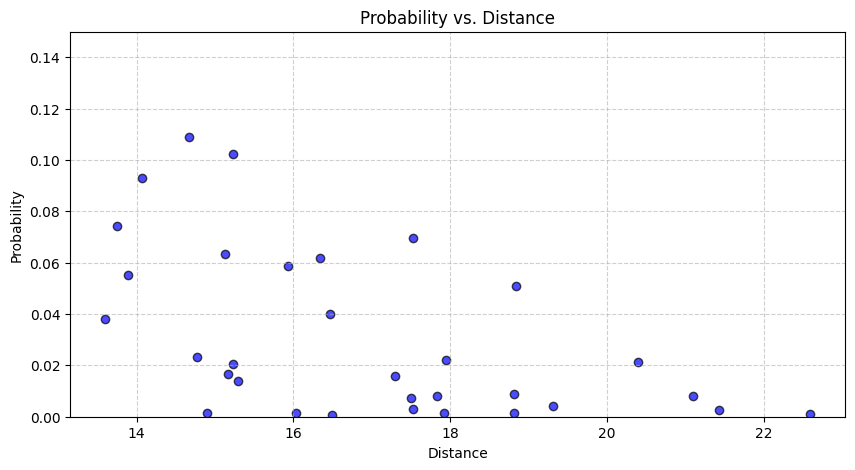

In [40]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.15) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()